## LAB 1: Introduction to Python and Libraries for Machine Learning, Environmental Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    r2_score, mean_absolute_error, mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Cleaned-Data.csv')
df.head()


,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,...,Gender_Female,Gender_Male,Gender_Transgender,Severity_Mild,Severity_Moderate,Severity_None,Severity_Severe,Contact_Dont-Know,Contact_No,Contact_Yes
0,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,0,0,0,0,1
1,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,0,0,0,1,0
2,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,0,0,1,0,0
3,1,1,1,1,1,0,1,1,1,1,...,0,1,0,0,1,0,0,0,0,1
4,1,1,1,1,1,0,1,1,1,1,...,0,1,0,0,1,0,0,0,1,0


## LAB 2: Handling Missing Values, Normalization, Standardization, and Data Visualization

Missing values in each column:
Fever                      0
Tiredness                  0
Dry-Cough                  0
Difficulty-in-Breathing    0
Sore-Throat                0
None_Sympton               0
Pains                      0
Nasal-Congestion           0
Runny-Nose                 0
Diarrhea                   0
None_Experiencing          0
Age_0-9                    0
Age_10-19                  0
Age_20-24                  0
Age_25-59                  0
Age_60+                    0
Gender_Female              0
Gender_Male                0
Gender_Transgender         0
Severity_Mild              0
Severity_Moderate          0
Severity_None              0
Severity_Severe            0
Contact_Dont-Know          0
Contact_No                 0
Contact_Yes                0
dtype: int64


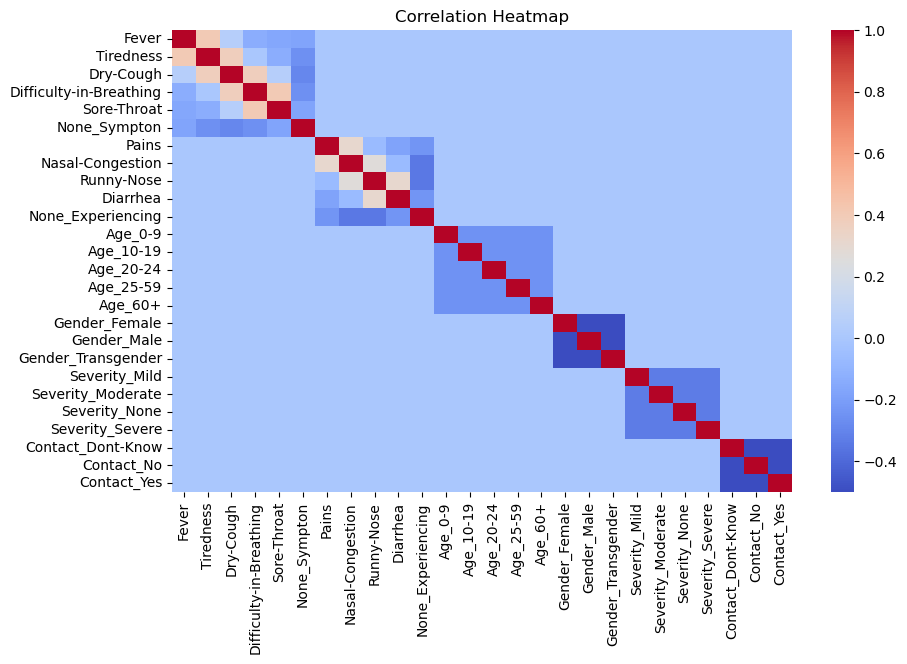

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## LAB 3: Data Preprocessing (Correlation, Outlier Detection, Feature Engineering, Data Splitting)

In [8]:
df['target'] = df['Severity_Mild'] + df['Severity_Moderate'] + df['Severity_Severe']
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe',])

X = df.drop(columns=['target'])
y = df['target']

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).sum()
print("Outliers per feature:\n", outliers)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Outliers per feature:
 Fever                          0
Tiredness                      0
Dry-Cough                      0
Difficulty-in-Breathing        0
Sore-Throat                    0
None_Sympton               19800
Pains                          0
Nasal-Congestion               0
Runny-Nose                     0
Diarrhea                       0
None_Experiencing          28800
Age_0-9                    63360
Age_10-19                  63360
Age_20-24                  63360
Age_25-59                  63360
Age_60+                    63360
Gender_Female                  0
Gender_Male                    0
Gender_Transgender             0
Contact_Dont-Know              0
Contact_No                     0
Contact_Yes                    0
dtype: int64


## LAB 5: Logistic Regression and Model Evaluation using R², MAE, MSE

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


Accuracy: 0.7513099747474747
R²: -0.33100854988131
MAE: 0.24869002525252526
MSE: 0.24869002525252526


## LAB 6: Implementing Decision Tree

In [14]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Accuracy: 0.7513099747474747
Confusion Matrix:
 [[    0 15757]
 [    0 47603]]
Precision: 0.7513099747474747
Recall: 1.0
F1 Score: 0.8579977109486946


from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

svm = LinearSVC(max_iter=10000)  # Higher iteration limit for convergence
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))


## LAB 7: Implementing Support Vector Machine

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))


## LAB 8: Evaluation Metrics - Accuracy, Confusion Matrix, ROC-AUC, Precision, Recall, F1-Score

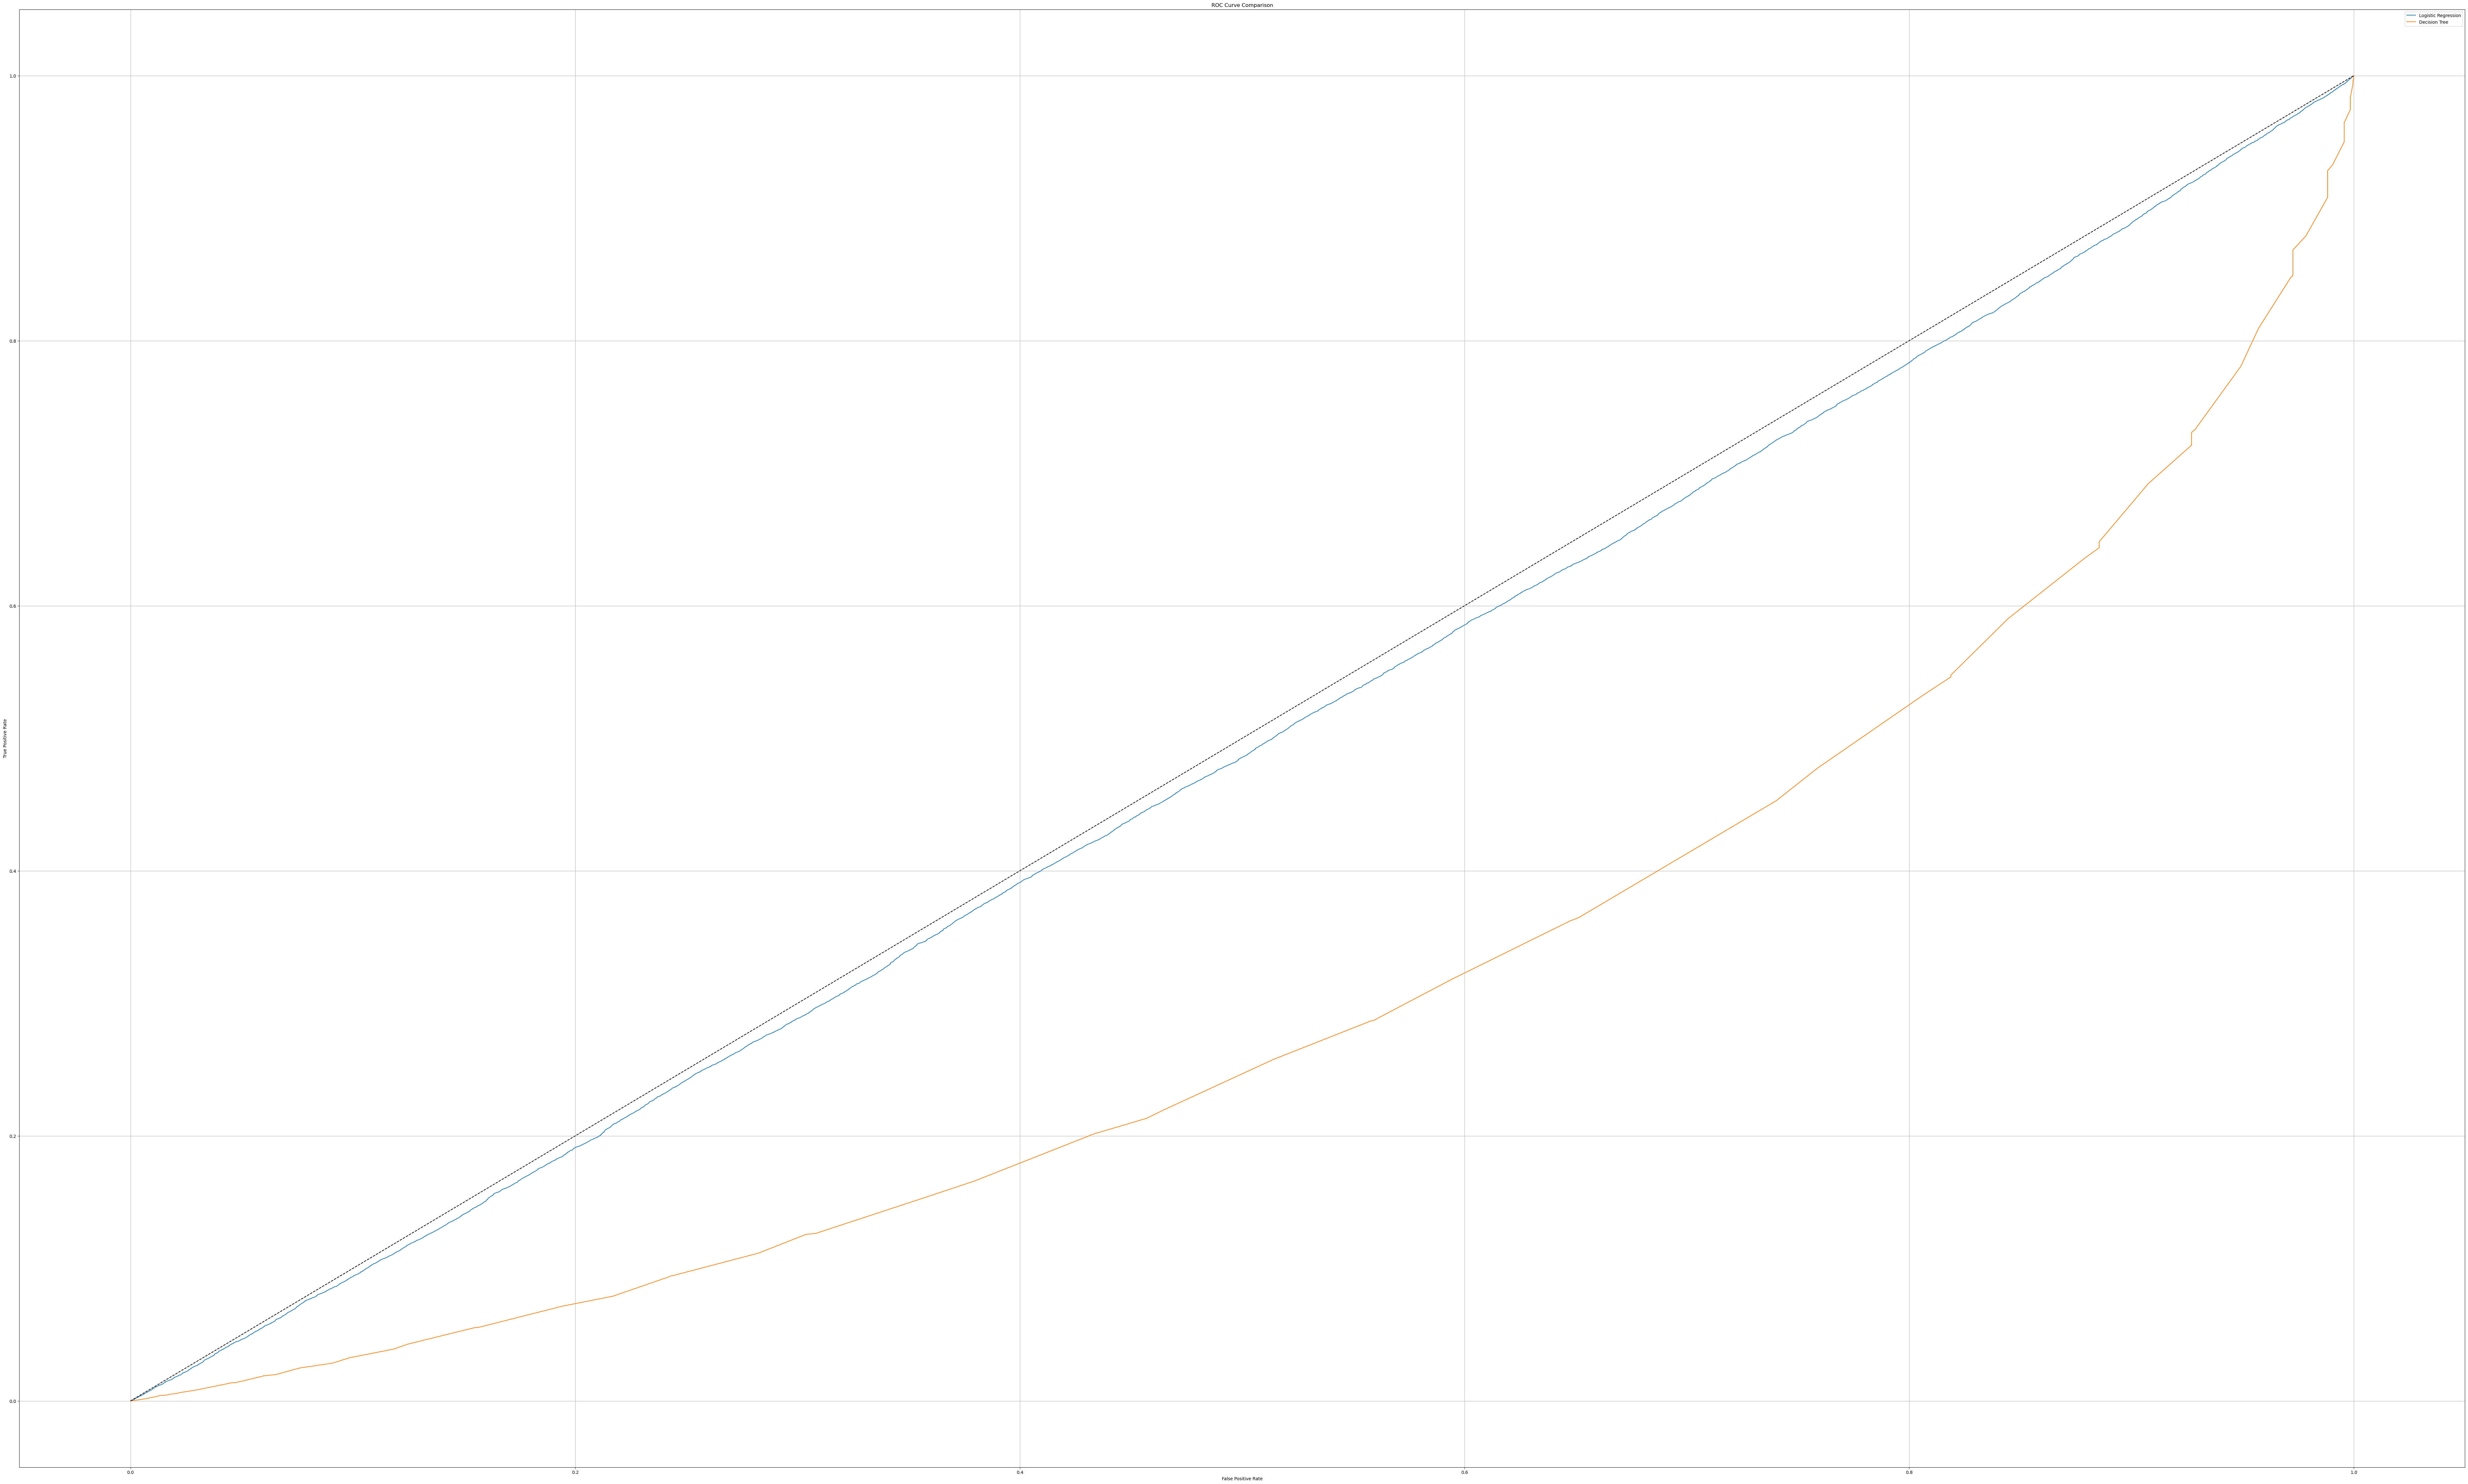

In [26]:
plt.figure(figsize=(100, 60))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])
# fpr_svm, tpr_svm, _ = roc_curve(y_test, svm.predict_proba(X_test)[:,1])

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
# plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()


In [ ]:
def user_input():
    print("Enter symptoms (yes/no):")
    features = {}
    for feature in X.columns:
        val = input(f"{feature}: ").lower()
        features[feature] = 1 if val == 'yes' else 0
    return pd.DataFrame([features])

user_df = user_input()
prediction = lr.predict(user_df)[0]
if prediction == 1:
    print("Prediction: COVID Positive")
else:
    print("Prediction: COVID Negative")


Enter symptoms (yes/no):


Fever:  yes
